## Differential Evolution

Let us start by importing the required libraries and defining the crossover probability and the mutation factor

In [1]:
import numpy as np
import random

p_cr = 0.5
F = 2

A donor vector can be defined by easily defined by sampling three vectors from an existing population

In [2]:
def donor_vector(pop):
    a, b, c = random.choices(pop, k=3)
    return a + F * (b - c)

The trial vector can be constructed by simply iterating across all $m$ positions of a vector. Recall that at least one position (namely $I_\mathrm{rnd}$) is obtained by the donor vector.

In [3]:
def trial_vector(x, v):
    m = len(x)
    I_rnd = np.random.randint(0, m-1)
    u = np.zeros(m)
    for i in range(0, m):
        if np.random.random() < p_cr:
            u[i] = v[i]
        else:
            u[i] = x[i]
    u[I_rnd] = v[I_rnd]
    return u

Selection only requires comparing with the newly generated individual with its parent:

In [4]:
def selection(x, u, fit):
    if fit(x) < fit(u):
        return x
    else:
        return u

And a generation is a simple concatenation of these operations for all individuals of the population

In [5]:
def generation(pop, fit):
    next_gen = []
    for i in range(0, len(pop)):
        v = donor_vector(pop)
        u = trial_vector(pop[i], v)
        next_gen.append(selection(pop[i], u, fit))
    return next_gen

We can now define differential evolution. To sample the search space in a uniform way we need to pass the dimensions for is as arguments. In this case a list of pairs of the form $[x_\mathrm{min}, x_\mathrm{max}]$.

The function returns both the last population and the history of all generations.

In [6]:
def differential_evolution(n_gens, pop_size, search_space, fit):
    pop = []
    hist = []
    n = len(search_space)
    for i in range(0, pop_size):
        pop.append(np.array([np.random.uniform(search_space[i][0], search_space[i][1])
                             for i in range(0, n)]))
    hist.append(pop)
    for i in range(0, n_gens):
        pop = generation(pop, fit)
        hist.append(pop)
    return pop, hist

### DE on the Ackley function

The Ackley function in two dimensions is defined as:

$f(x, y) = -20\,\mathrm{exp}\left(-0.2 \sqrt{0.5(x^2 + y^2)}\right) - \mathrm{exp}\left( 0.5 (\cos(2\pi x) + \cos(2\pi y))\right) + e + 20$

the search space is $[-5, 5]^2$ and the global optimum is in $(0,0)$.

The function is characterized by a large number of local minima.

In [7]:
def ackley(x, y):
    return -20 * np.exp(-0.2 * np.sqrt(0.5 * (x**2 + y**2))) - np.exp(0.5 * (np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y))) + np.e + 20

We can now define a function to plot the Ackley function and a collection of points on it.

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_ackley(pop):
    ax = plt.figure(figsize=(20,10)).add_subplot(projection='3d')
    xvals = np.linspace(-5, 5, 201)
    yvals = np.linspace(-5, 5, 201)
    xx, yy = np.meshgrid(xvals, yvals)
    z = ackley(xx, yy)
    ax.plot_surface(xx, yy, z, antialiased=True, alpha=0.2)
    x_pop = [p[0] for p in pop]
    y_pop = [p[1] for p in pop]
    z_pop = [ackley(p[0], p[1]) for p in pop]
    ax.scatter(x_pop, y_pop, z_pop, c="red")
    return ax

Let us run the differential evolution and look at how the solutions converge near the global optimum.

In [33]:
np.random.seed(0)
random.seed(0)
last, hist = differential_evolution(50, 10, [[-5, 5], [-5, 5]], lambda p: ackley(*p))

<Axes3D: >

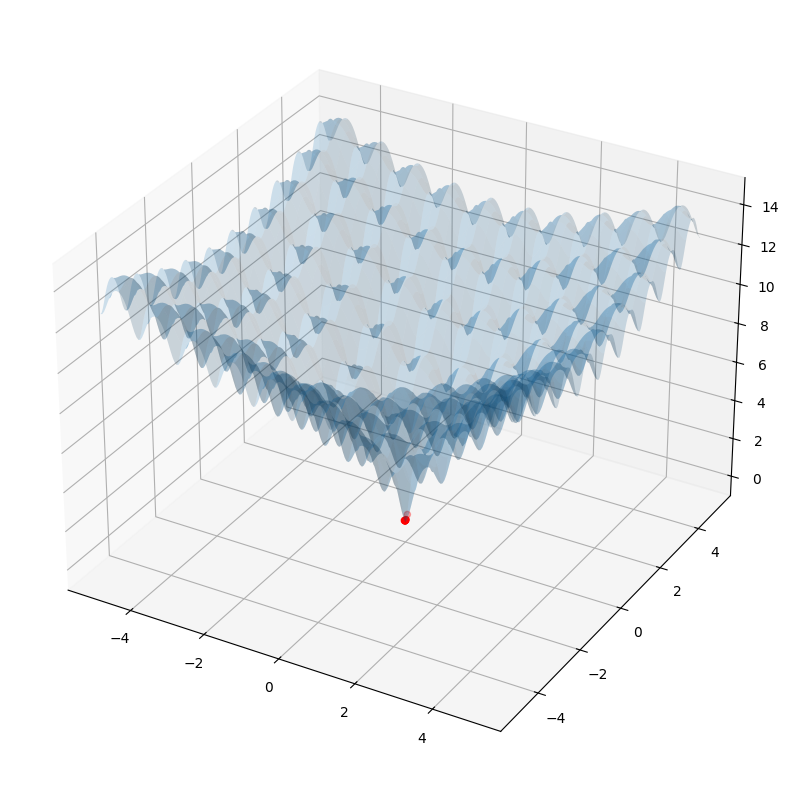

In [34]:
plot_ackley(hist[-1])

## Particle Swarm Optimization

First of all, we start by setting a series of parameters for PSO

In [11]:
c_soc = 1.49445
c_cog = 1.49445
w = 0.8

We can define how to update the position. Most of the code is to deal with the case when a particle goes outside the boundary of the search space. In this case the approach that we will take is the "dampened" one.

In [12]:
def update_position(position, velocity, boundaries):
    new_position = position + velocity
    for i, b in enumerate(boundaries):
        if new_position[i] < b[0]:
            new_position[i] = b[0]
            velocity[i] = - np.random.random() * velocity[i]
        elif new_position[i] > b[1]:
            new_position[i] = b[1]
            velocity[i] = - np.random.random() * velocity[i]
    return new_position

Updating the velocity can be done by splitting the update in the sum of three vectors, the social component, the cognitive component, and the inertia. The rest of the code only have to deal with keeping the velocities inside the allowed range of values.

In [13]:
def update_velocity(position, velocity, global_best, local_best, max_velocities):
    n = len(velocity)
    r1 = np.random.random(n)
    r2 = np.random.random(n)
    social_component = c_soc * r1 * (global_best - position)
    cognitive_component = c_cog * r2 * (local_best - position)
    inertia = w*velocity
    new_velocity = inertia + social_component + cognitive_component
    for i, v in enumerate(max_velocities):
        if np.abs(new_velocity[i]) < v[0]:
            new_velocity[i] = np.sign(new_velocity[i]) * v[0]
        elif np.abs(new_velocity[i]) > v[1]:
            new_velocity[i] = np.sign(new_velocity[i]) * v[1]
    return new_velocity

PSO can now be define. Differently from DE, in addition to the particle position we need:

- the particle velocity
- the local best for each particle
- the global best

The function returns, in addition to the global best, the history of the entire optimization process.

In [14]:
def pso(swarm_size, boundaries, max_velocities, n_iter, fit):
    m = len(boundaries)
    positions = [np.array([np.random.random() * (b[1] - b[0]) + b[0] for b in boundaries])
                 for i in range(0, swarm_size)]
    velocities = [np.array([np.random.choice([-1,1]) * np.random.uniform(v[0],v[1])
                            for v in max_velocities]) for i in range(0, swarm_size)]
    local_best = positions
    global_best = min(positions, key=fit)
    hist = [positions]
    for i in range(0, n_iter):
        velocities = [update_velocity(p, v, global_best, lb, max_velocities)
                      for p, v, lb in zip(positions, velocities, local_best)]
        positions = [update_position(p, v, boundaries) for p, v in zip(positions, velocities)]
        local_best = [min([p, lb], key=fit) for p, lb in zip(positions, local_best)]
        global_best = min([min(positions, key=fit), global_best], key=fit)
        hist.append(positions)
    return global_best, hist

We can now test PSO on the Ackley function:

In [15]:
np.random.seed(0)
best, hist = pso(10, [[-5, 5], [-5, 5]], [[0.001, 1], [0.001, 1]], 50, lambda p: ackley(*p))

<Axes3D: >

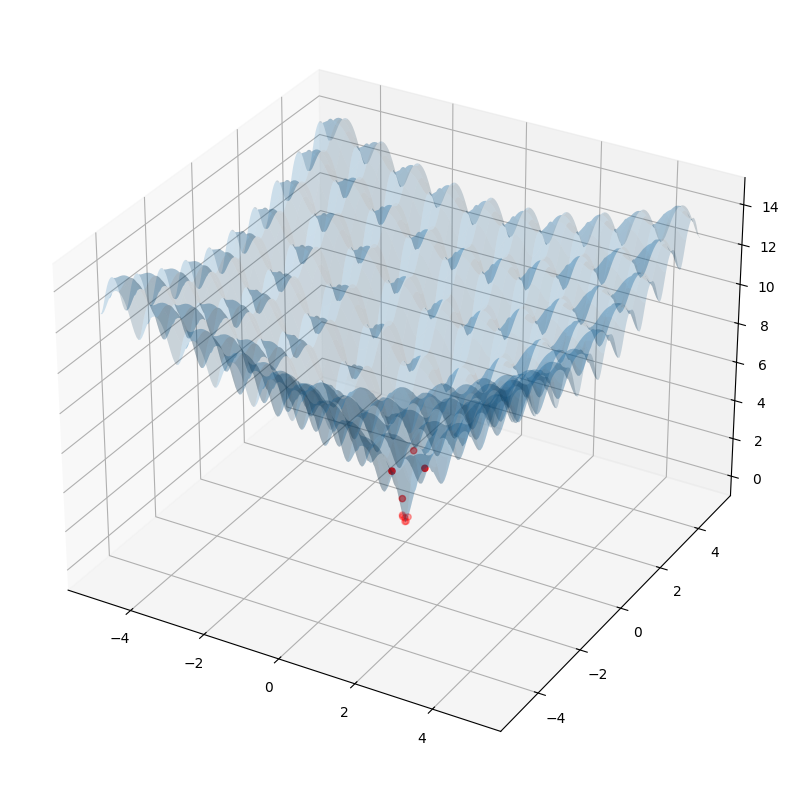

In [16]:
plot_ackley(hist[50])